In [2]:
import numpy as np
from rds import get_rds_connection
from dotenv import load_dotenv
load_dotenv()

True

In [61]:
top_10_cat = [
    'math.AP', 'math.CO', 'math.AG', 'math.PR', 'math.NT',
    'math.DG', 'math.DS', 'math.FA', 'math.RT', 'math.GR'
]

n_per_cat = 5000
placeholders = ', '.join(['%s'] * len(top_10_cat))

QUERY = f"""
WITH ranked AS (
    SELECT
        embedding,
        primary_category,
        ROW_NUMBER() OVER (
            PARTITION BY primary_category
            ORDER BY RANDOM()
        ) AS rn
    FROM theorem_search_qwen
    TABLESAMPLE SYSTEM (2)
    WHERE
        source = 'arXiv'
        AND primary_category IN ({placeholders})
)
SELECT
    embedding,
    primary_category
FROM ranked
WHERE rn <= %s;
"""

conn = get_rds_connection()
cur = conn.cursor()

cur.execute(QUERY, top_10_cat + [n_per_cat])
rows = cur.fetchall()

cur.close()
conn.close()

X = np.array([row[0] for row in rows])
y = np.array([row[1] for row in rows])

print(X.shape)


(50000, 1024)


In [62]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import umap

X_scaled = StandardScaler().fit_transform(X)
X_pca50 = PCA(n_components=50, random_state=42).fit_transform(X_scaled)

X_umap = umap.UMAP(
    n_neighbors=30,
    min_dist=0.1,
    metric="cosine",
    random_state=42
).fit_transform(X_pca50)

print(X_umap.shape)  # (n_samples, 2)

C:\Users\sls70\PycharmProjects\MathCopilot\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


(50000, 2)


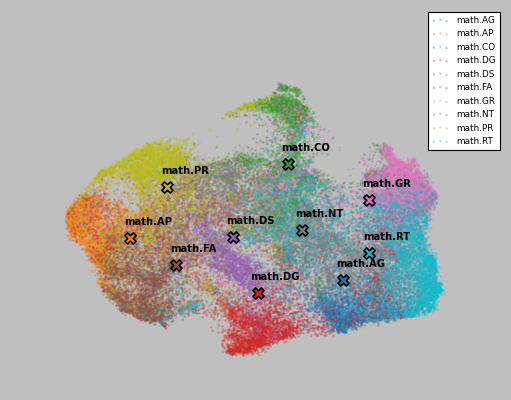

In [84]:
import matplotlib.pyplot as plt
import numpy as np

cats = np.unique(y)
cmap = plt.cm.tab10
cat_to_color = {
    cat: cmap(i / len(cats))
    for i, cat in enumerate(cats)
}

centroids = {
    cat: X_umap[y == cat].mean(axis=0)
    for cat in cats
}

plt.figure(figsize=(8, 6))

for cat in cats:
    idx = y == cat
    plt.scatter(
        X_umap[idx, 0],
        X_umap[idx, 1],
        s=2,
        alpha=0.25,
        color=cat_to_color[cat],
        label=cat
    )

# plot centroids (same color, larger, distinct marker)
for cat, c in centroids.items():
    plt.text(
        c[0] + 0.5, c[1] + 0.5,
        cat,
        fontsize=9,
        weight='semibold',
        ha='center',
        va='center'
    ),
    plt.scatter(
        c[0], c[1],
        marker='X',
        s=100,
        color=cat_to_color[cat],
        edgecolors='black',
        linewidths=1.5,
        zorder=10
    )

plt.axis('off')
plt.xlabel("UMAP-1")
plt.ylabel("UMAP-2")
plt.legend(fontsize=8)
plt.show()

In [3]:
import numpy as np
import umap
from dotenv import load_dotenv
from sklearn.decomposition import PCA

from rds import get_rds_connection

load_dotenv()

TOP_10 = [
    'math.AP','math.CO','math.AG','math.PR','math.NT',
    'math.DG','math.DS','math.FA','math.RT','math.GR'
]

PER_CAT = 1000
RANDOM_STATE = 42

SQL = """SELECT
  s.theorem_id,
  s.primary_category,
  r.embedding AS raw_embedding,
  g.embedding AS slogan_embedding
FROM arxiv_umap_sample s
JOIN raw_theorem_embedding_gemma r
  ON r.theorem_id = s.theorem_id
JOIN theorem_slogan ts
  ON ts.theorem_id = s.theorem_id
JOIN theorem_embedding_gemma g
  ON g.slogan_id = ts.slogan_id;"""

conn = get_rds_connection()
cur = conn.cursor()

cur.execute(SQL, {"cats": TOP_10, "per_cat": PER_CAT})
rows = cur.fetchall()

cur.close()
conn.close()

In [4]:
cats = np.array([r[1] for r in rows])
X_raw = np.array([r[2] for r in rows], dtype=np.float32)
X_slogan = np.array([r[3] for r in rows], dtype=np.float32)

def l2_normalize(X, eps=1e-12):
    return X / np.maximum(np.linalg.norm(X, axis=1, keepdims=True), eps)

# Normalize
X_raw = l2_normalize(X_raw)
X_slogan = l2_normalize(X_slogan)

X_all = np.vstack([X_raw, X_slogan])

# PCA
pca = PCA(n_components=50, random_state=RANDOM_STATE)
X_all_pca = pca.fit_transform(X_all)

reducer = umap.UMAP(
    n_neighbors=30,
    min_dist=0.1,
    n_components=2,
    metric="cosine",
    random_state=RANDOM_STATE
)

Z_all = reducer.fit_transform(X_all_pca)

Z_raw = Z_all[:len(X_raw)]
Z_slogan = Z_all[len(X_raw):]

C:\Users\sls70\PycharmProjects\MathCopilot\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


In [8]:
def compute_centroids(Z, labels, categories):
    centroids = {}
    for cat in categories:
        mask = labels == cat
        centroids[cat] = Z[mask].mean(axis=0)
    return centroids

raw_centroids = compute_centroids(Z_raw, cats, TOP_10)
slogan_centroids = compute_centroids(Z_slogan, cats, TOP_10)

In [15]:
import matplotlib as mpl

mpl.rcParams.update({
    "figure.dpi": 300,
    "savefig.dpi": 300,
    "font.size": 14,
    "axes.titlesize": 18,
    "axes.labelsize": 16,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "legend.fontsize": 14,
})

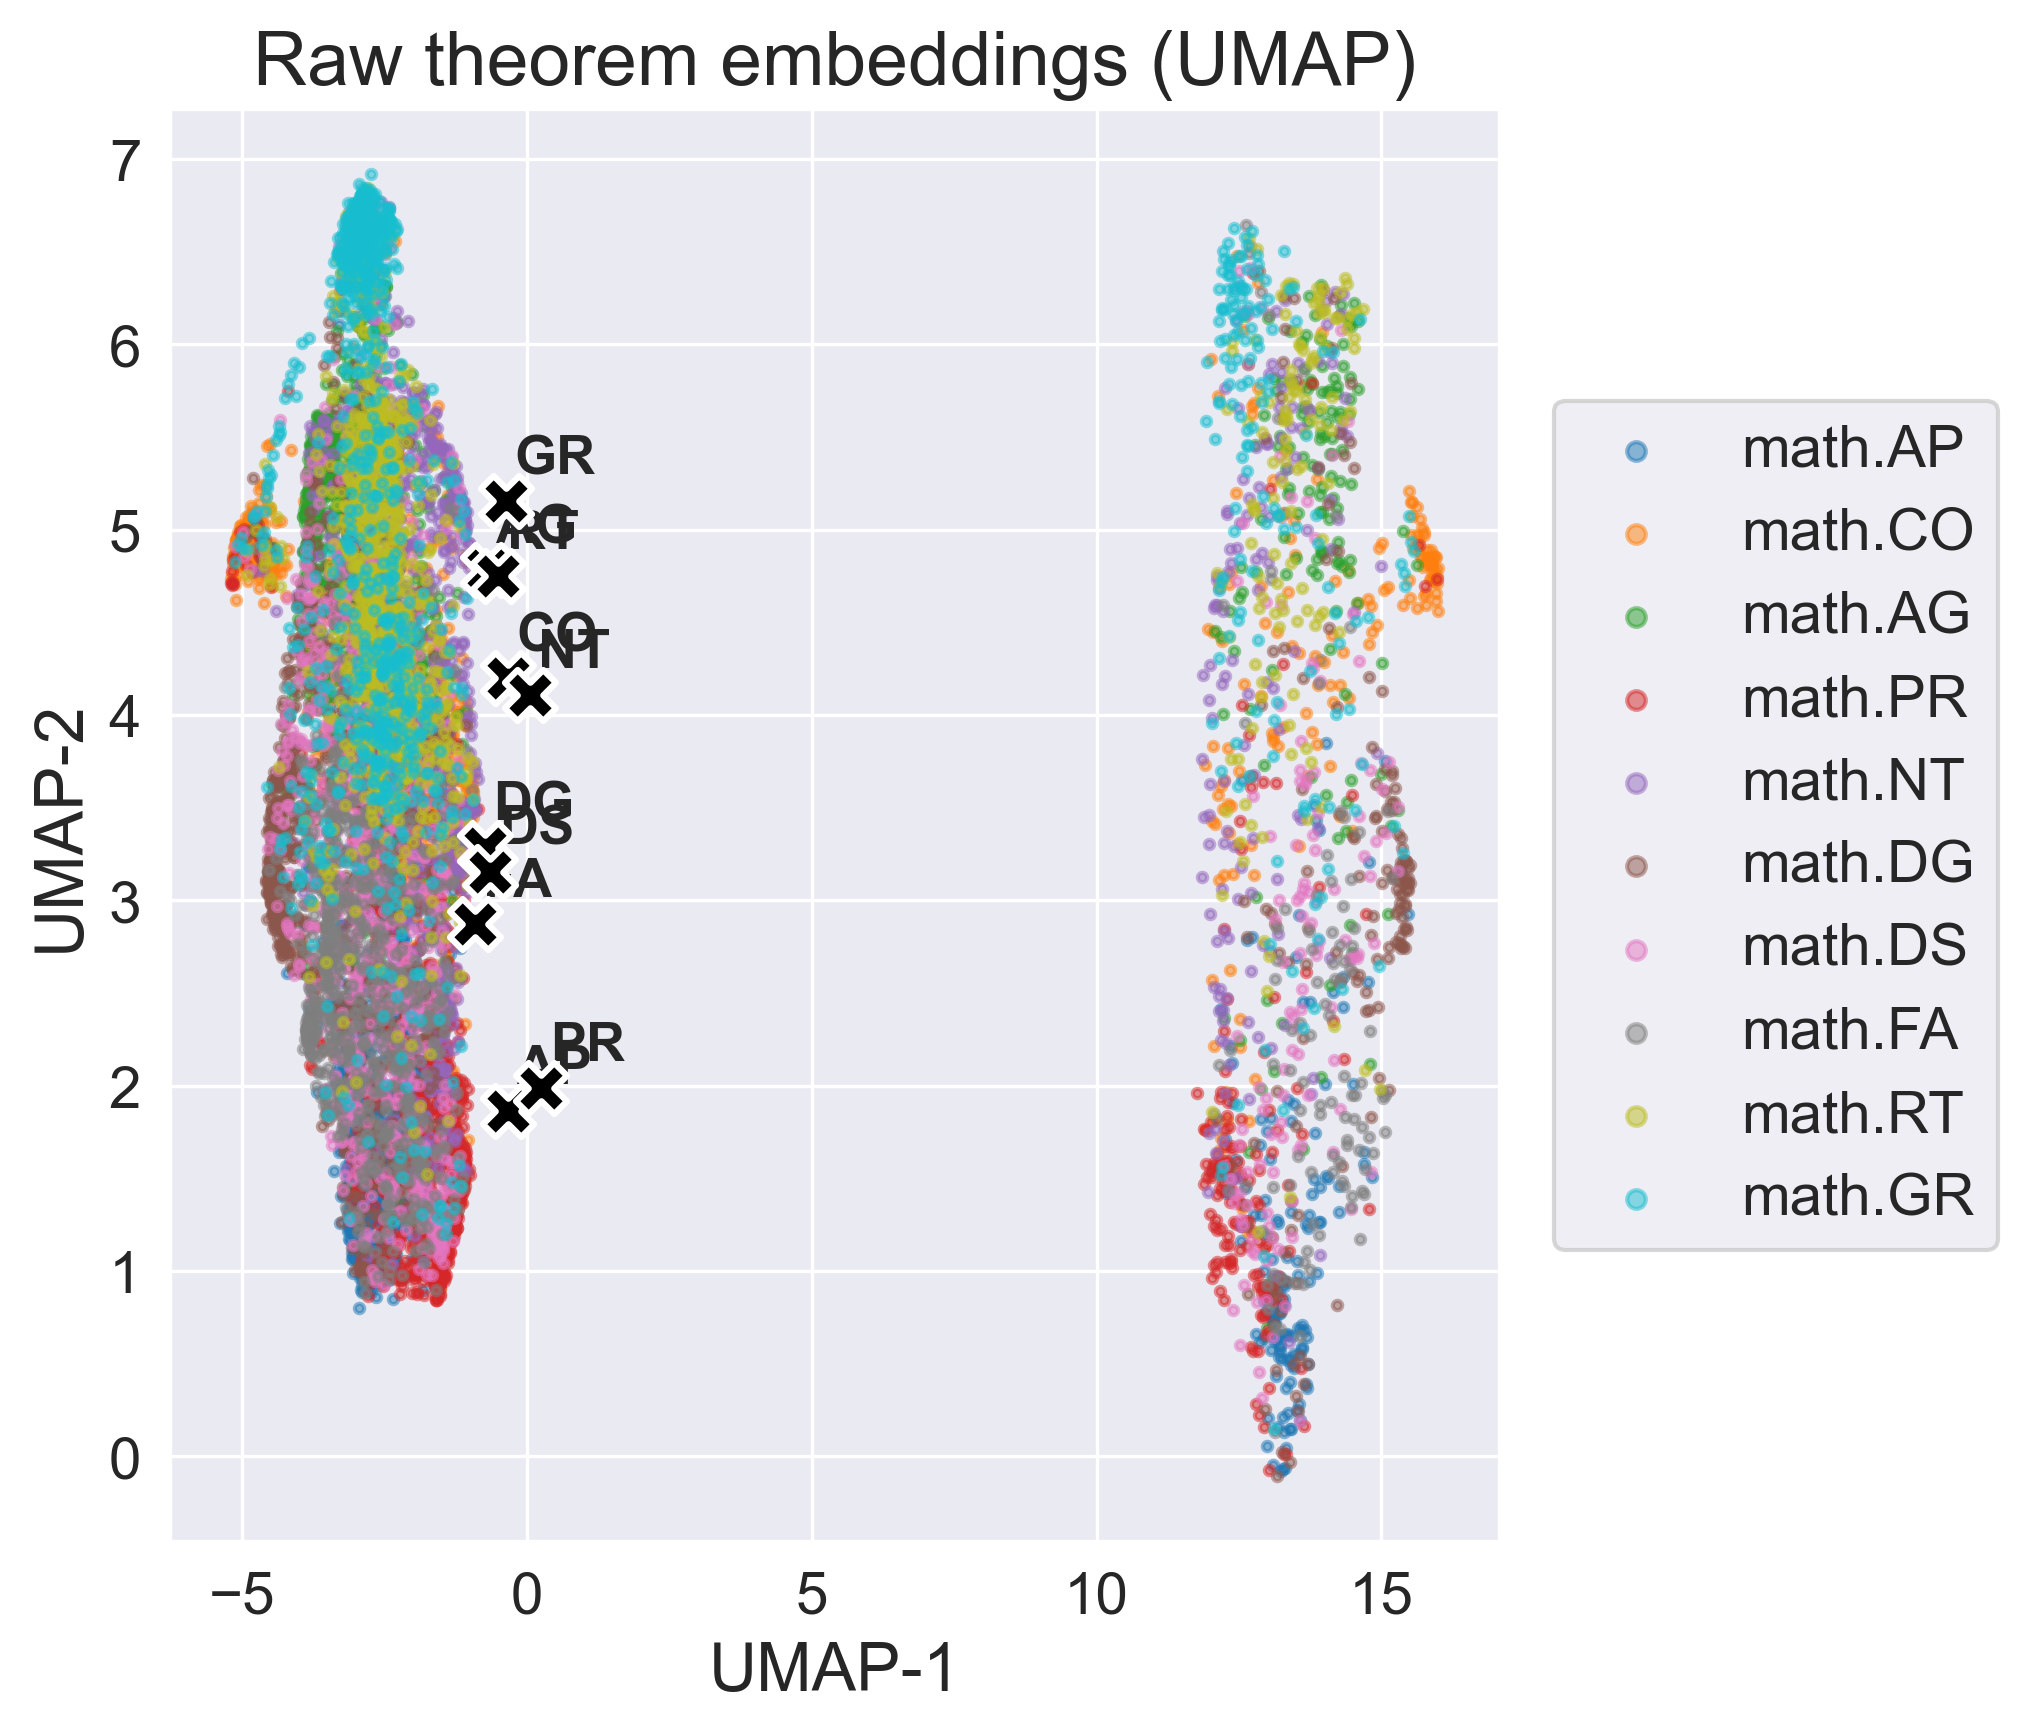

In [29]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 6))

for cat in TOP_10:
    mask = cats == cat
    plt.scatter(
        Z_raw[mask, 0],
        Z_raw[mask, 1],
        s=5,
        alpha=0.5,
        label=cat
    )

# Centroids
for cat in TOP_10:
    cx, cy = raw_centroids[cat]
    plt.scatter(
        cx, cy,
        marker='X',
        s=150,
        c='black',
        edgecolors='white',
        linewidths=1.5,
        zorder=10
    )
    plt.text(
        cx + 0.15,
        cy + 0.15,
        cat[5:],
        fontsize=13,
        weight='bold'
    )

plt.title("Raw theorem embeddings (UMAP)")
plt.xlabel("UMAP-1")
plt.ylabel("UMAP-2")

plt.legend(
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    markerscale=2
)

plt.tight_layout()
plt.show()


In [ ]:
plt.savefig("raw_theorem_umap.png", dpi=300, bbox_inches="tight")
plt.savefig("raw_theorem_umap.pdf", bbox_inches="tight")

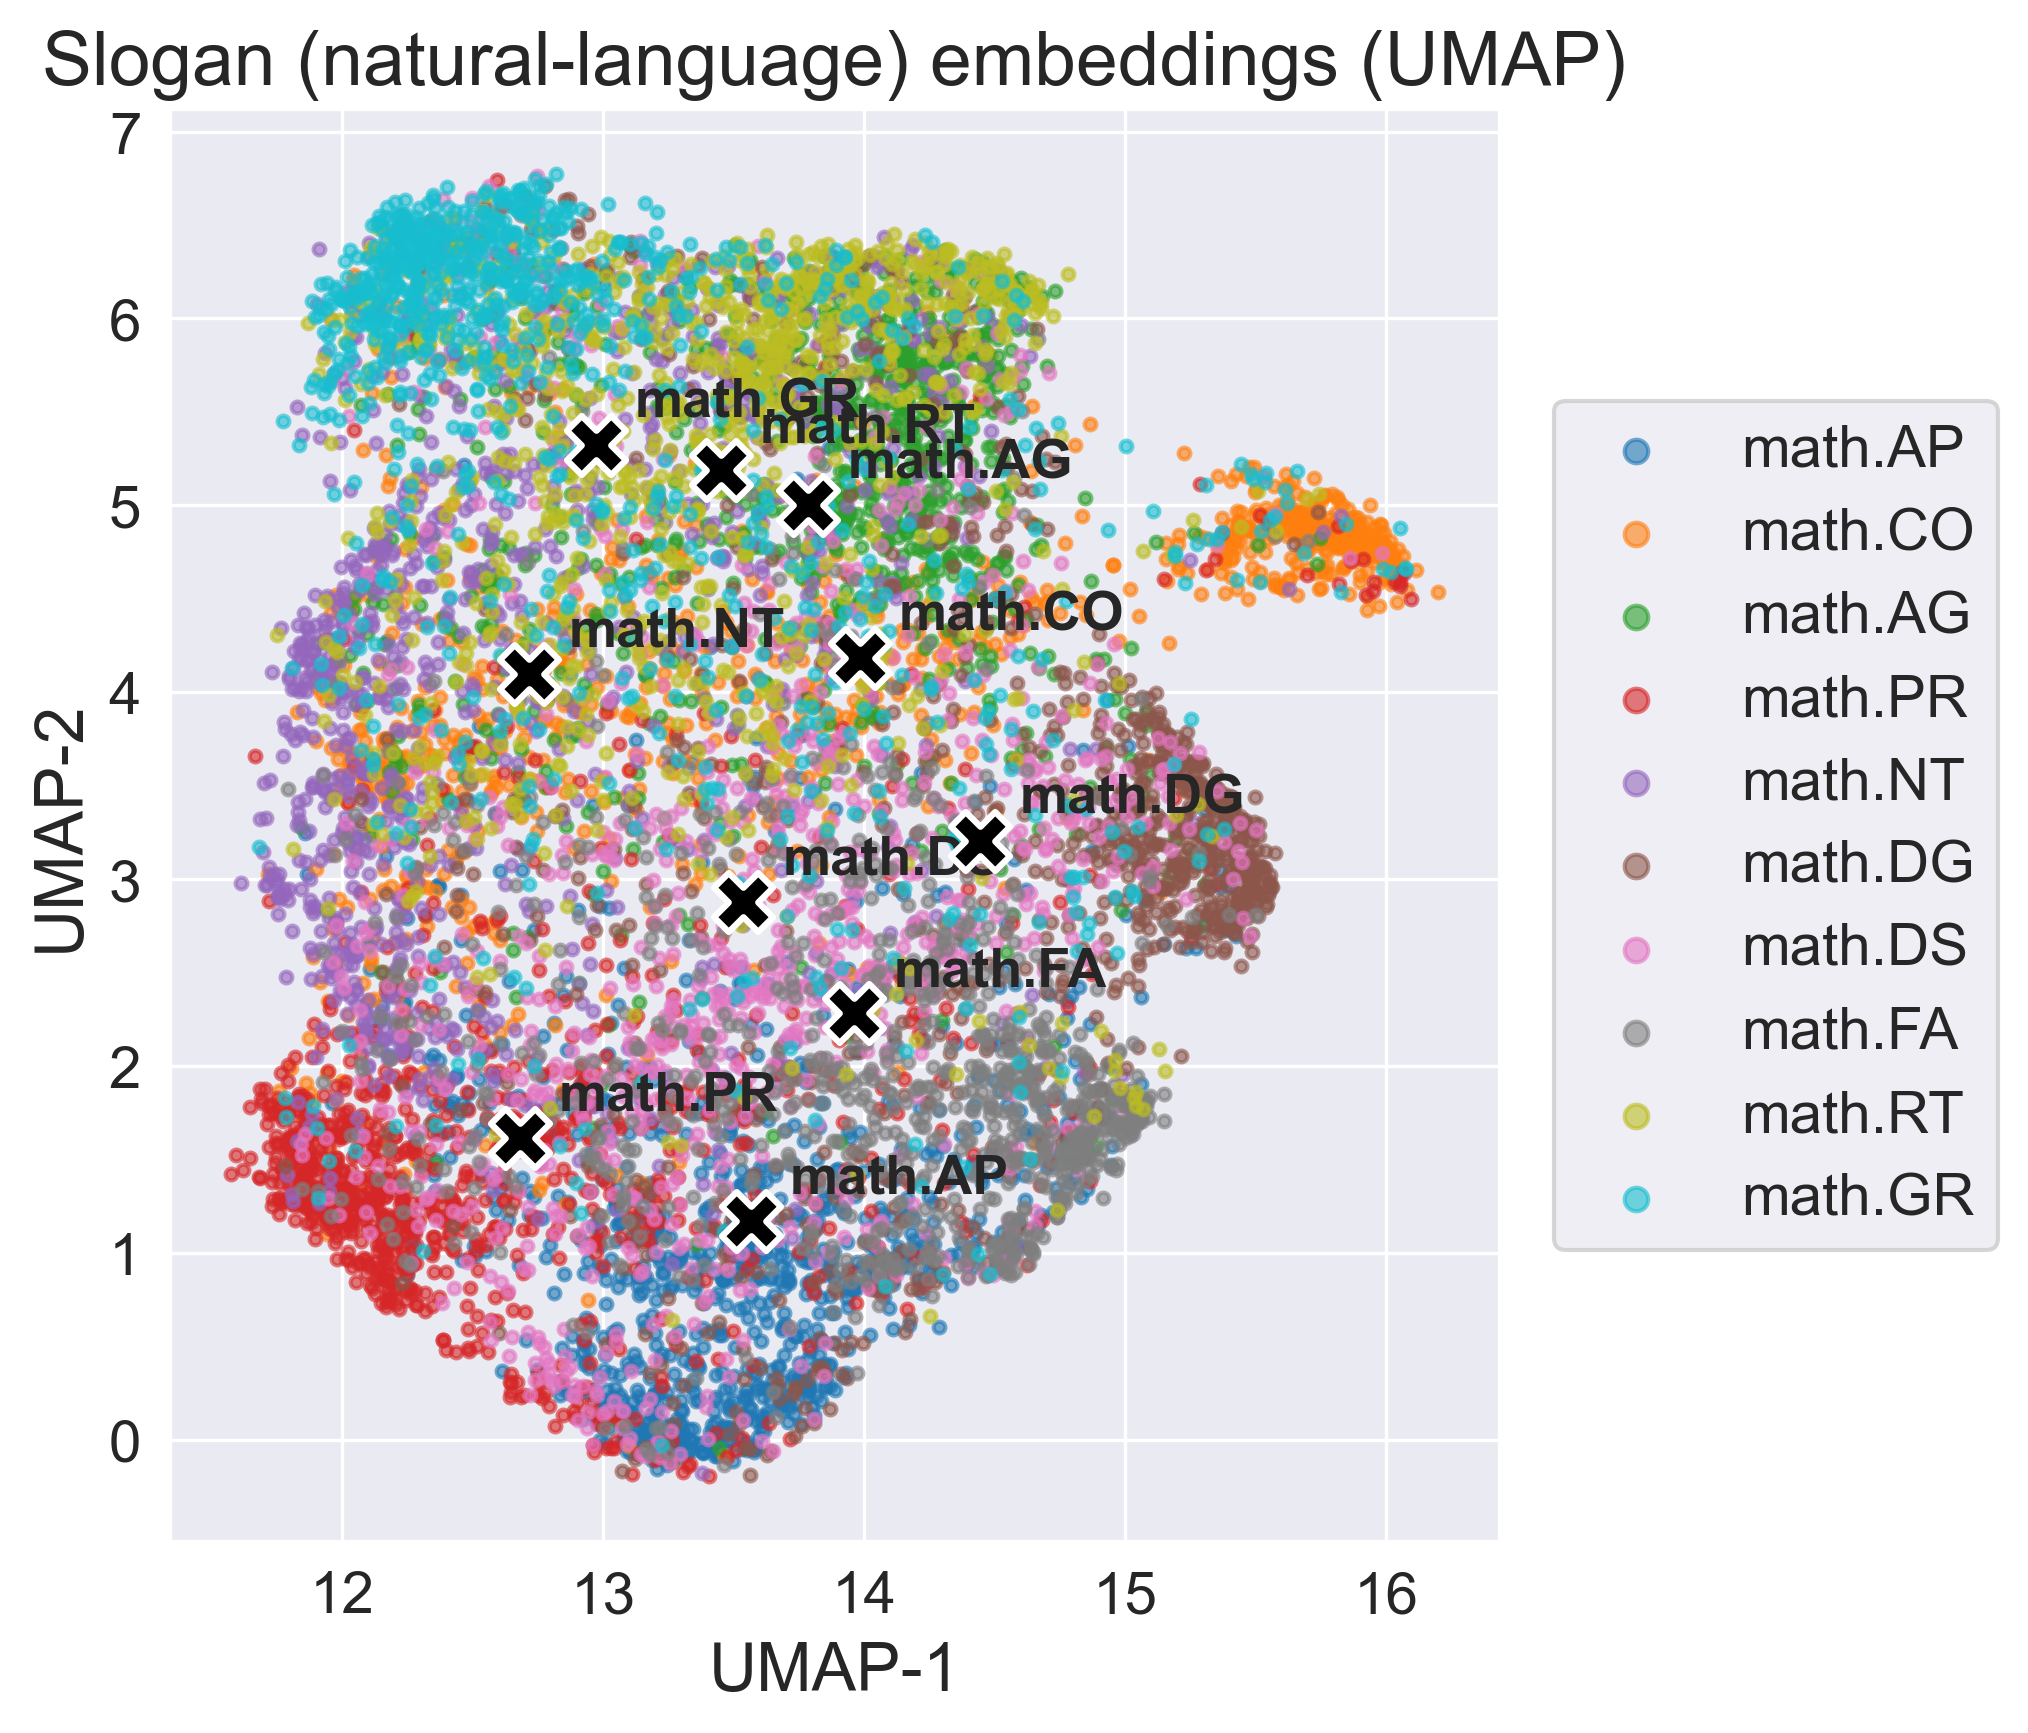

In [17]:
plt.figure(figsize=(7, 6))

for cat in TOP_10:
    mask = cats == cat
    plt.scatter(
        Z_slogan[mask, 0],
        Z_slogan[mask, 1],
        s=8,
        alpha=0.6,
        label=cat
    )

# Centroids
for cat in TOP_10:
    cx, cy = slogan_centroids[cat]
    plt.scatter(
        cx, cy,
        marker='X',
        s=200,
        c='black',
        edgecolors='white',
        linewidths=1.5,
        zorder=10
    )
    plt.text(
        cx + 0.15,
        cy + 0.15,
        cat,
        fontsize=13,
        weight='bold'
    )

plt.title("Slogan (natural-language) embeddings (UMAP)")
plt.xlabel("UMAP-1")
plt.ylabel("UMAP-2")

plt.legend(
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    markerscale=2
)

plt.tight_layout()
plt.show()

In [ ]:
plt.savefig("slogan_theorem_umap.png", dpi=300, bbox_inches="tight")
plt.savefig("slogan_theorem_umap.pdf", bbox_inches="tight")

In [30]:
mask_ag = cats == "math.AG"

X_raw_ag = X_raw[mask_ag]
X_slogan_ag = X_slogan[mask_ag]

print("math.AG sample size:", X_raw_ag.shape[0])

X_raw_ag = l2_normalize(X_raw_ag)
X_slogan_ag = l2_normalize(X_slogan_ag)

# Fit PCA on combined data
X_all_ag = np.vstack([X_raw_ag, X_slogan_ag])

pca = PCA(n_components=2, random_state=42)
Z_all_ag = pca.fit_transform(X_all_ag)

Z_raw_ag = Z_all_ag[:len(X_raw_ag)]
Z_slogan_ag = Z_all_ag[len(X_raw_ag):]

math.AG sample size: 1002


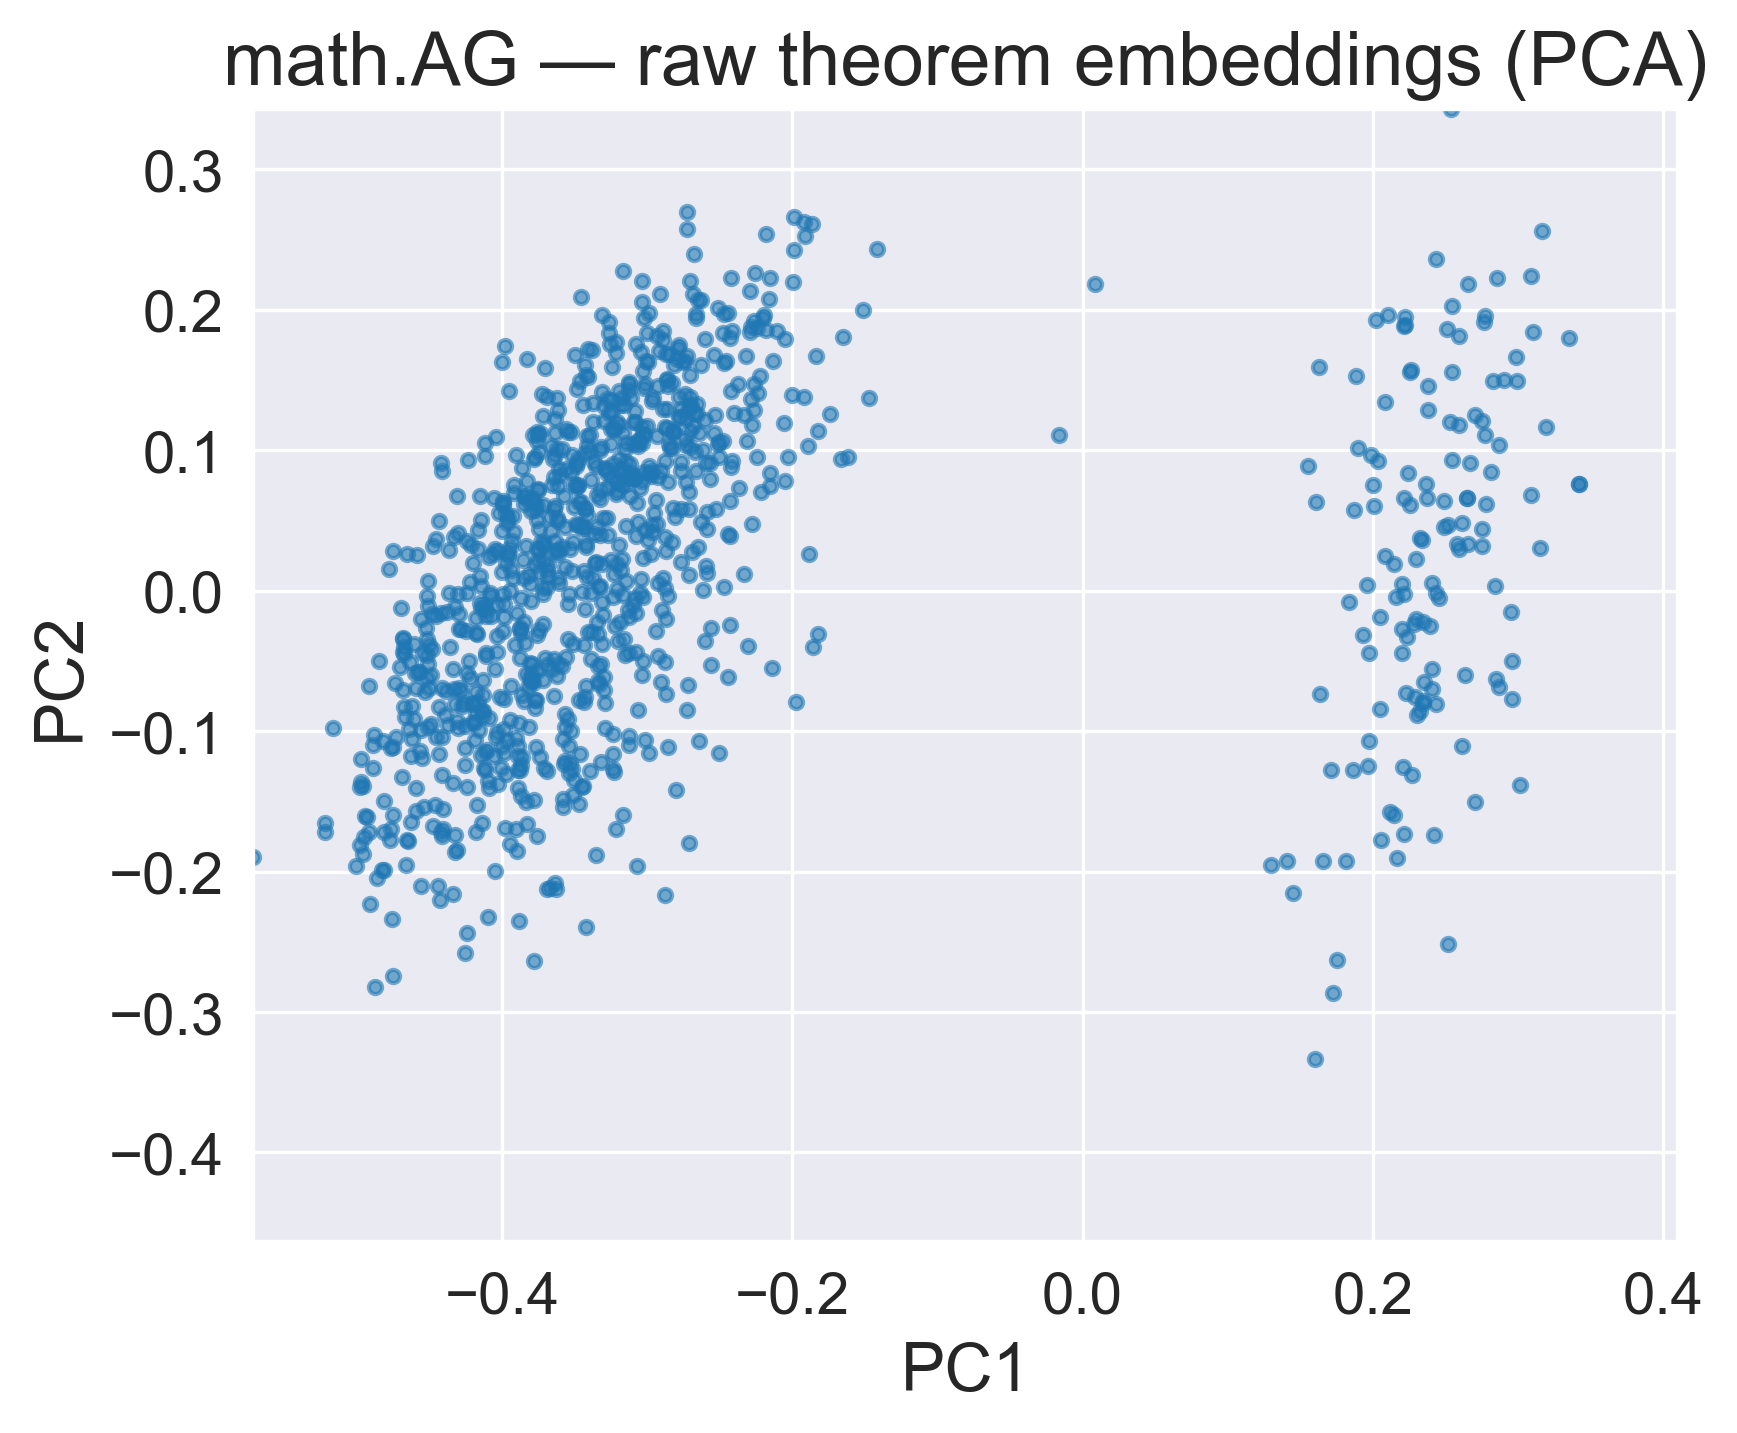

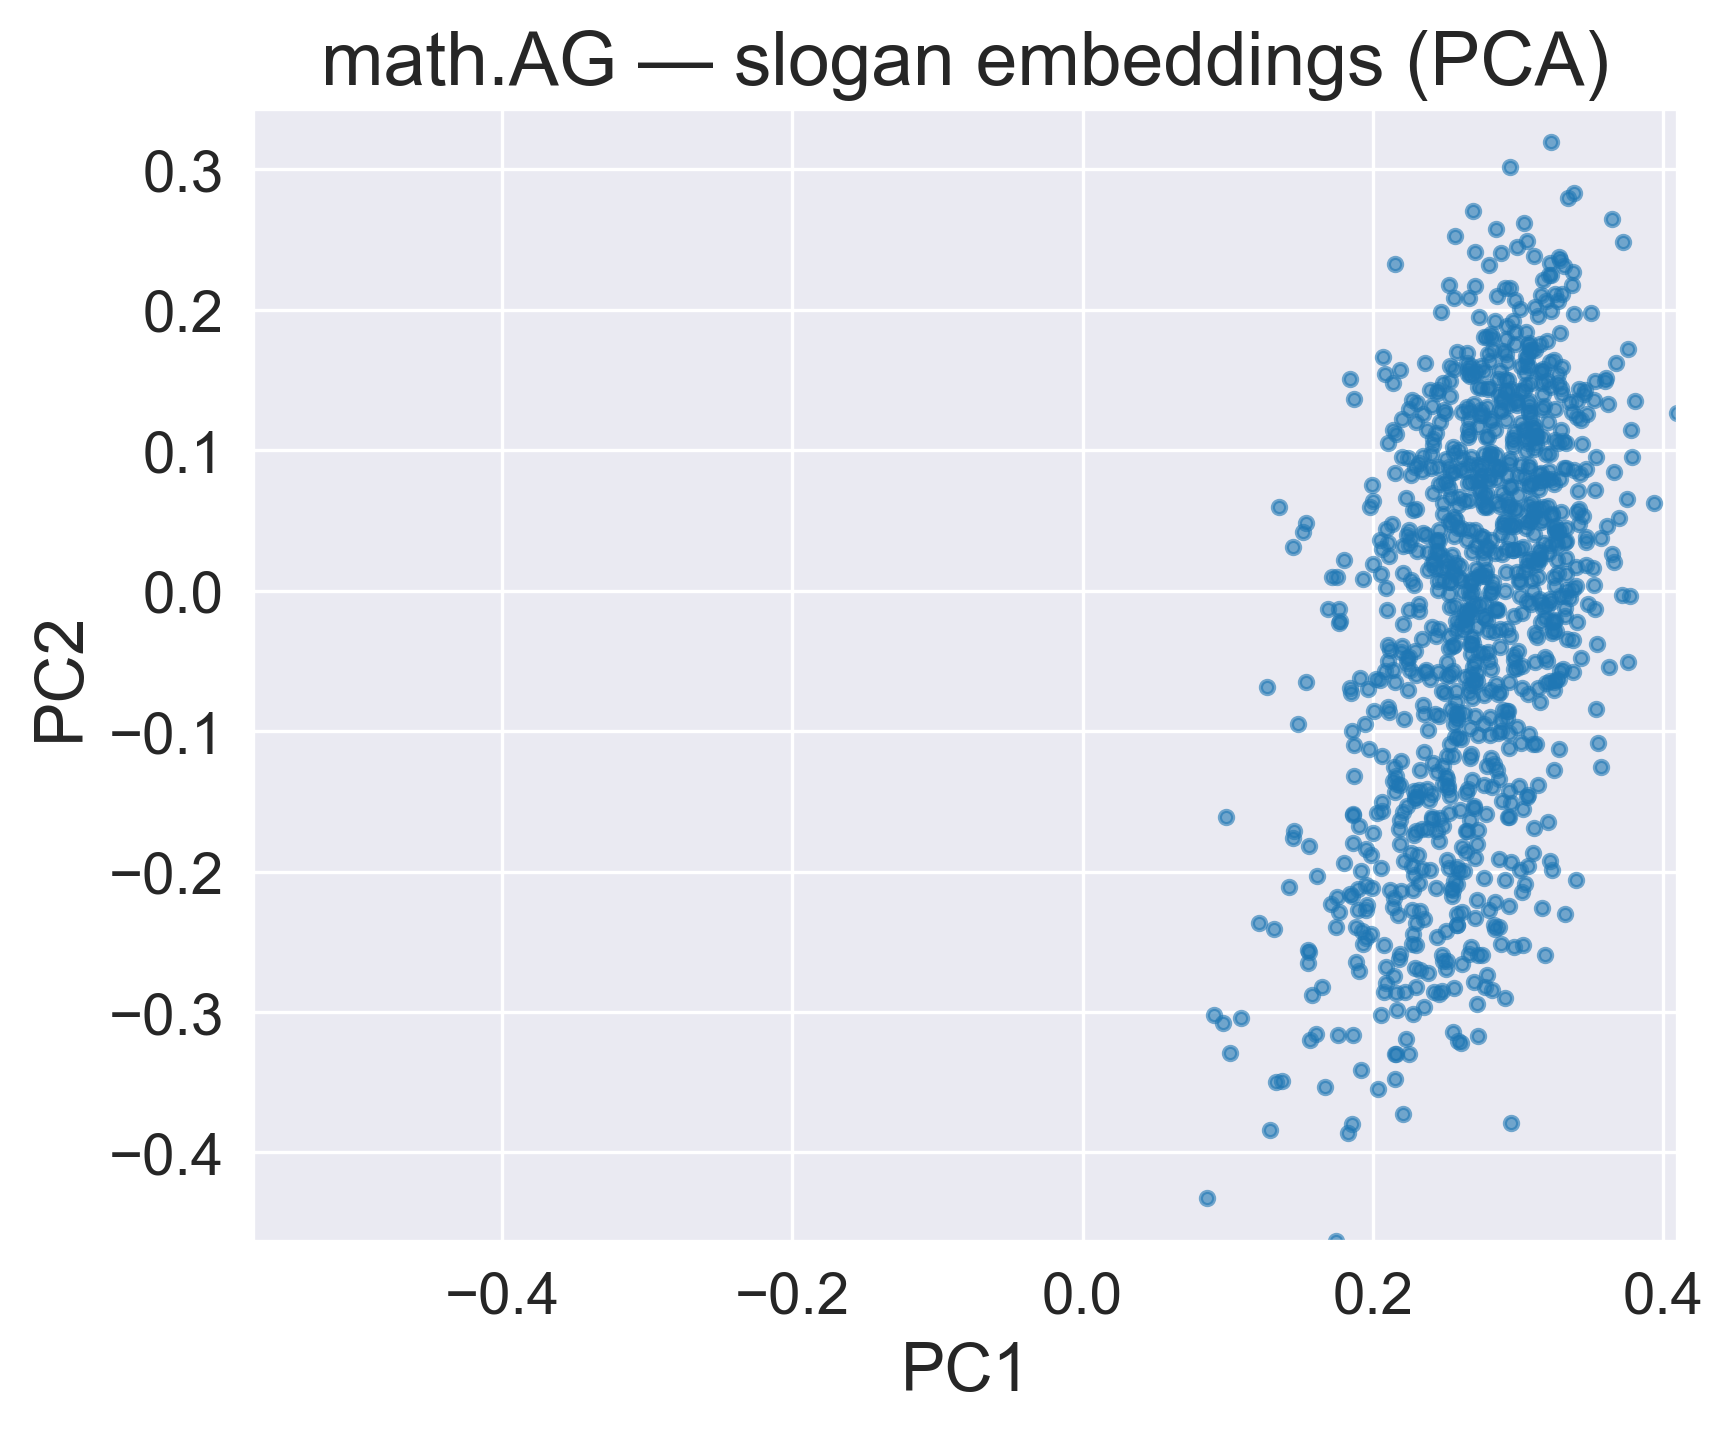

In [31]:
# Shared axis values
Z_all = np.vstack([Z_raw_ag, Z_slogan_ag])
xlim = (Z_all[:, 0].min(), Z_all[:, 0].max())
ylim = (Z_all[:, 1].min(), Z_all[:, 1].max())

# Raw
plt.figure(figsize=(6, 5))
plt.scatter(Z_raw_ag[:, 0], Z_raw_ag[:, 1], s=10, alpha=0.6)
plt.xlim(xlim)
plt.ylim(ylim)
plt.title("math.AG — raw theorem embeddings (PCA)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.tight_layout()
plt.show()

# Slogan
plt.figure(figsize=(6, 5))
plt.scatter(Z_slogan_ag[:, 0], Z_slogan_ag[:, 1], s=10, alpha=0.6)
plt.xlim(xlim)
plt.ylim(ylim)
plt.title("math.AG — slogan embeddings (PCA)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.tight_layout()
plt.show()

In [33]:
theorem_ids = np.array([r[0] for r in rows])

np.percentile(Z_raw[:, 0], [5, 25, 50, 75, 95])

left_mask  = Z_raw[:, 0] < 0
right_mask = Z_raw[:, 0] > 0

In [42]:
rng = np.random.default_rng(42)

left_indices = rng.choice(
    np.where(left_mask)[0],
    size=10,
    replace=False
)

right_indices = rng.choice(
    np.where(right_mask)[0],
    size=10,
    replace=False
)

left_theorem_ids  = theorem_ids[left_indices]
right_theorem_ids = theorem_ids[right_indices]

left_theorem_ids, right_theorem_ids

(array([21730157, 20433387, 23687779, 25944313, 24728806, 25882219,
        23344775, 19384059, 18475267, 26390535]),
 array([17477257, 24104368, 12296574, 17937873, 25794824, 19231987,
        22901053, 20358994, 17924739, 17492240]))

In [43]:
def fetch_theorem_bodies(theorem_ids):
    theorem_ids = [int(x) for x in theorem_ids]
    conn = get_rds_connection()
    cur = conn.cursor()

    cur.execute(
        """
        SELECT theorem_id, body
        FROM theorem
        WHERE theorem_id = ANY(%s)
        """,
        (list(theorem_ids),)
    )

    rows = cur.fetchall()
    cur.close()
    conn.close()

    return {tid: body for tid, body in rows}

left_bodies  = fetch_theorem_bodies(left_theorem_ids)
right_bodies = fetch_theorem_bodies(right_theorem_ids)

In [44]:
from IPython.display import display, Markdown

def show_bodies(title, bodies):
    display(Markdown(f"## {title}"))
    for tid, body in bodies.items():
        display(Markdown(f"**Theorem ID {tid}**"))
        display(Markdown(f"```latex\n{body}\n```"))

show_bodies("Left manifold", left_bodies)
show_bodies("Right manifold", right_bodies)

## Left manifold

**Theorem ID 18475267**

```latex
Let $G$ be a theta-free graph and assume that $G$ does not admit a clique cutset. Let $(T, \chi )$ be a tight tree decomposition of $G$. Then for every edge $t_1t_2$ of $T$ the graph $G_{t_1\rightarrow t_2} \setminus \chi (t_1)$ is connected and $N(G_{t_1\rightarrow t_2} \setminus \chi (t_1))=\chi (t_1) \cap \chi (t_2)$. Moreover, if $t_0,t_1,t_2 \in V(T)$ and $t_1,t_2 \in N_T(t_0)$, then $\chi (t_0) \cap \chi (t_1) \neq \chi (t_0) \cap \chi (t_2)$.
```

**Theorem ID 19384059**

```latex
Let $\mathscr {X}$ that be an algebraic stack that is proper over an $I$-adically complete Noetherian ring $A$. Define $\mathscr {X}_n \coloneqq \mathscr {X} \times _A A/I^{n+1}$. Let $P_n \in D^-_{\operatorname {coh}}(\mathscr {X}_n)$ be an adic system of pseudo-coherent complexes. Then there exists a pseudo-coherent complex $P \in D^-_{\operatorname {coh}}(\mathscr {X})$ such that $L(j_{n,\operatorname {qc}})^\ast P \simeq P_n$.
```

...

```latex
Assume that $(n_i)$ is a not eventually periodic sequence such that the set ${\mathcal E}^{(n_i)}_b$ is nonempty. Then the set ${\mathcal E}^{(n_i)}_{\mathfrak {b}}$ is a point on the line segment $b-a=1$.
```

**Theorem ID 24104368**

```latex
In any Courant–Jacobi algebroid $(E;L)$ the following additional identities hold:\begin{enumerate}[label=(0)]\item  the VB morphism $\nabla :E\to DL$ induces a morphism of Loday algebras from $\Gamma (E)$ to $\mathcal{D}L$, i.e. 

\begin{equation}   \nabla _{[\! [e_1,e_2]\! ]}=[\nabla _{e_1},\nabla _{e_2}],\quad \text{for all $e_1,e_2\in \Gamma (E)$} \end{equation}

\item  the Loday bracket $[\! [-,-]\! ]$ satisfies the following Leibniz rule 

\begin{equation}   [\! [e_1,fe_2]\! ]=(\sigma (\nabla _{e_1})f)e_2+f[\! [e_1,e_2]\! ],\quad \text{for all $e_1,e_2\in \Gamma (E)$ and $f\in C^\infty (M)$}. \end{equation}

 In other words, the Loday algebra derivation $Z_e:=[\! [e,-]\! ]:\Gamma (E)\to \Gamma (E)$ is also a derivation of the vector bundle $E$, i.e.~ $Z_e\in \mathcal{D}E$, and $\sigma (Z_e)=\sigma (\nabla _e)$, for any $e\in \Gamma (E)$ 

\end{enumerate}
```

**Theorem ID 25794824**

```latex
If $Y(t)= R \Theta^*(t),t\in \mathbb{Z}^d$ with $R$ a unit Pareto rv independent of $\Theta^*$ which satisfies \eqref{eqDo2} and $\Theta^*(0)=1$ almost surely, then $Z_N$ given by
\begin{eqnarray} 
Z_N(t) = \frac{ B^N Y (t)}{\max_{i\in \mathbb{Z}^d} p_i  B^N Y(i) } \mathbb{I}{(  \mathcal{I}_{fm}( p \cdot B^N  Y ) =N)}  , \quad t\in \mathbb{Z}^d
\label{sm}
 \end{eqnarray}
is a spectral rf of some stationary max-stable  rf $X(t),t\in \mathbb{Z}^d$ with unit  {Fr \'{e}chet } marginals. Moreover, the spectral tail rf $\Theta$ of $X$   has the same law as $\Theta^*$.
```

In [46]:
left_ids = [int(x) for x in left_theorem_ids]
right_ids = [int(x) for x in right_theorem_ids]

import csv

with open("math_ag_sample.csv", "w", newline="", encoding="utf-8") as f:
    writer = csv.writer(
        f,
        quoting=csv.QUOTE_ALL
    )

    writer.writerow(["theorem_id", "manifold", "body"])

    for tid in left_ids:
        writer.writerow([
            tid,
            "left",
            left_bodies.get(tid, "")
        ])

    for tid in right_ids:
        writer.writerow([
            tid,
            "right",
            right_bodies.get(tid, "")
        ])